# Linguistic Analysis: The Peregrine Falcon

**Author:** Piotr Mioduszewski

## Introduction
The peregrine falcon (*Falco peregrinus*) is a fascinating bird known for its incredible speed and global distribution. As a subject for linguistic analysis, it provides a rich source of scientific and descriptive vocabulary.

**The goal of this project is to:**
* Scrape detailed textual data from the Wikipedia article on the peregrine falcon using `BeautifulSoup`.
* Perform basic linguistic analysis (tokenization and POS tagging) using `NLTK`.
* Explore and categorize word types, specifically focusing on nouns and adjectives.
* Visualize the most frequent linguistic patterns using `matplotlib`.

In [5]:
import requests
from bs4 import BeautifulSoup
import nltk
from nltk import word_tokenize, pos_tag
import matplotlib.pyplot as plt
from collections import Counter

# Pobranie niezbędnych plików do analizy języka angielskiego
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

## Data Acquisition
In this section, I perform web scraping to extract the raw text from the Peregrine Falcon Wikipedia page. I ensure to use headers to bypass access restrictions and gather the relevant content for linguistic processing.

In [8]:
# Adres URL artykułu
url = "https://en.wikipedia.org/wiki/Peregrine_falcon"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

paragraphs = soup.find_all('p')
text = ' '.join([p.text for p in paragraphs])

# Tokenizacja i tagowanie
tokens = word_tokenize(text.lower())
tagged_words = pos_tag(tokens)

print(f"Downloaded {len(tokens)} words for the analysis.")
print("Sample of 10 words and parts of speech:")
print(tagged_words[:10])

Downloaded 6643 words for the analysis.
Sample of 10 words and parts of speech:
[('18–19', 'CD'), (',', ','), ('see', 'VBP'), ('text', 'IN'), ('the', 'DT'), ('peregrine', 'NN'), ('falcon', 'NN'), ('(', '('), ('falco', 'JJ'), ('peregrinus', 'NN')]


## Linguistic Analysis
Here, I tokenize the text and use NLTK's Part-of-Speech tagger to categorize every word. This allows me to isolate nouns and adjectives, which are essential for understanding the descriptive nature of the article.

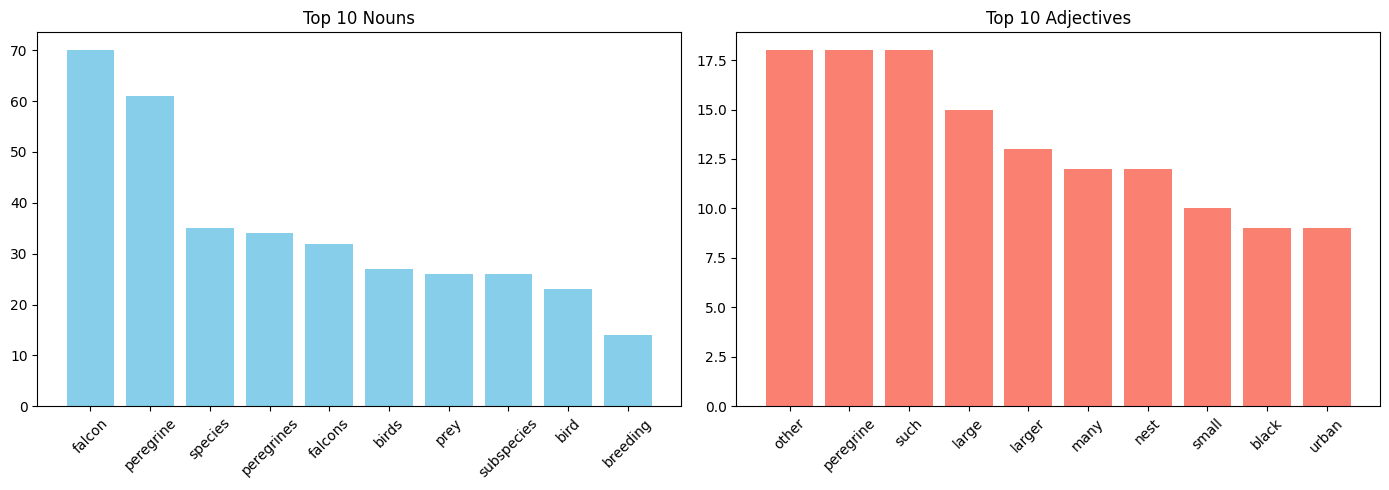

In [9]:
# Filtrowanie:
words_only = [word for word, tag in tagged_words if word.isalpha()]

# Rozdzielenie na rzeczowniki i przymiotniki
nouns = [word for word, tag in pos_tag(words_only) if tag.startswith('NN')]
adjectives = [word for word, tag in pos_tag(words_only) if tag.startswith('JJ')]

# Zliczanie najczęstszych
noun_counts = Counter(nouns).most_common(10)
adj_counts = Counter(adjectives).most_common(10)

# Przygotowanie danych do wykresu
n_words, n_counts = zip(*noun_counts)
a_words, a_counts = zip(*adj_counts)

# Tworzenie wykresów
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(n_words, n_counts, color='skyblue')
ax1.set_title("Top 10 Nouns")
ax1.tick_params(axis='x', rotation=45)

ax2.bar(a_words, a_counts, color='salmon')
ax2.set_title("Top 10 Adjectives")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Interpretation of Results

The linguistic analysis of the Wikipedia article about the Peregrine Falcon reveals a high density of biological and technical terminology.

* **Nouns:** The most frequent nouns, such as "falcon," "species," "peregrines," and "prey," clearly indicate that the text is focused on the classification and natural behavior of the bird. The dominance of these terms confirms the encyclopedic nature of the article.
* **Adjectives:** The adjective list, including words like "large," "small," "urban," and "black," highlights the descriptive aspect of the text, often used to define the physical characteristics and habitat of the species.
* **Conclusion:** Overall, the language used is highly informational and objective, which is typical for scientific encyclopedic writing. The analysis successfully visualizes how the article balances naming the subject with descriptive features.